**Load Data**

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Raw Class Distribution**

Class
0    284315
1       492
Name: count, dtype: int64


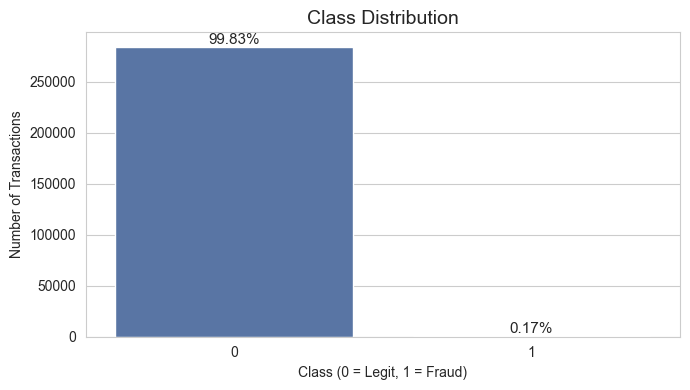

In [9]:
counts = df['Class'].value_counts()
total = len(df)
print(counts)

plt.figure(figsize=(7,4))
sns.set_style("whitegrid")

ax = sns.countplot(
    x='Class',
    hue='Class',
    data=df,
    palette=['#4C72B0', '#DD8452'],
    legend=False
)

plt.title('Class Distribution', fontsize=14)
plt.xlabel('Class (0 = Legit, 1 = Fraud)')
plt.ylabel('Number of Transactions')

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.annotate(f'{percentage:.2f}%',
                (p.get_x() + p.get_width()/2., count),
                ha='center', va='bottom',
                fontsize=11)

plt.tight_layout()
plt.show()

**Log-Scale Visualization**

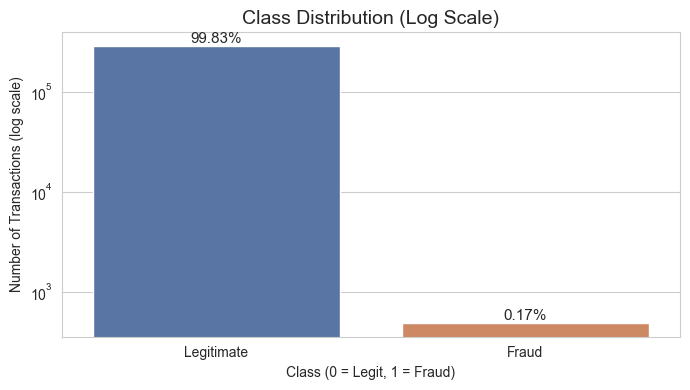

In [11]:
plt.figure(figsize=(7,4))
sns.set_style("whitegrid")

ax = sns.countplot(
    x='Class',
    hue='Class',
    data=df,
    palette=['#4C72B0', '#DD8452'],
    legend=False
)

plt.title('Class Distribution (Log Scale)', fontsize=14)
plt.xlabel('Class (0 = Legit, 1 = Fraud)')
plt.ylabel('Number of Transactions (log scale)')
plt.yscale('log')

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    
    ax.annotate(f'{percentage:.2f}%',
                (p.get_x() + p.get_width()/2., count),
                ha='center',
                va='bottom',
                fontsize=11)

plt.xticks([0,1], ['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

**Inspect Transaction Amounts**

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


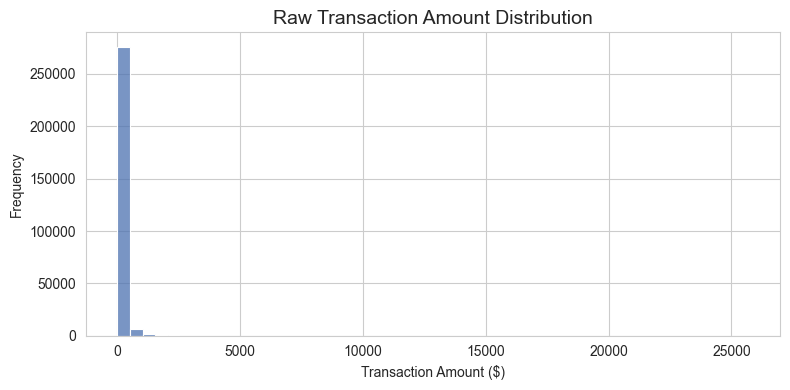

In [14]:
print(df['Amount'].describe())

plt.figure(figsize=(8,4))
sns.set_style("whitegrid")

ax = sns.histplot(
    df['Amount'],
    bins=50,
    color='#4C72B0'
)

plt.title('Raw Transaction Amount Distribution', fontsize=14)
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Outlier Problem Identified**

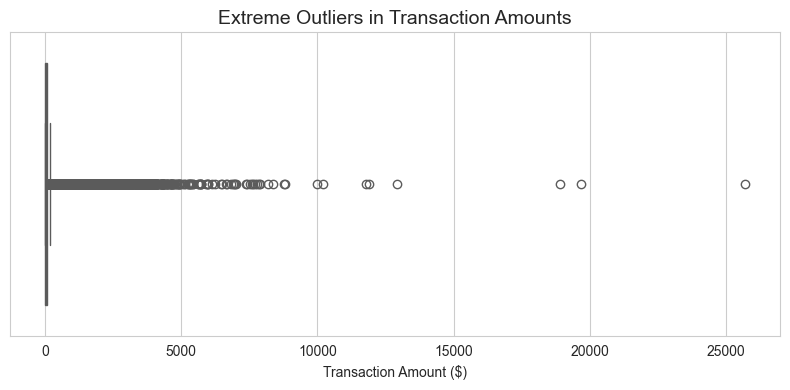

Median transaction amount: $22.00
Maximum transaction amount: $25691.16

Conclusion:
The large gap between the median and maximum value indicates extreme outliers.
StandardScaler would be heavily influenced by these values.
RobustScaler, which uses the median and IQR, is better suited for this feature.


In [20]:
plt.figure(figsize=(8,4))
sns.set_style("whitegrid")

ax = sns.boxplot(
    x=df['Amount'],
    color='#DD8452'
)

plt.title('Extreme Outliers in Transaction Amounts', fontsize=14)
plt.xlabel('Transaction Amount ($)')

plt.tight_layout()
plt.show()

# Engineering interpretation
median = df['Amount'].median()
max_value = df['Amount'].max()

print(f"Median transaction amount: ${median:.2f}")
print(f"Maximum transaction amount: ${max_value:.2f}")
print("\nConclusion:")
print("The large gap between the median and maximum value indicates extreme outliers.")
print("StandardScaler would be heavily influenced by these values.")
print("RobustScaler, which uses the median and IQR, is better suited for this feature.")

**Analyzing the Time Feature**

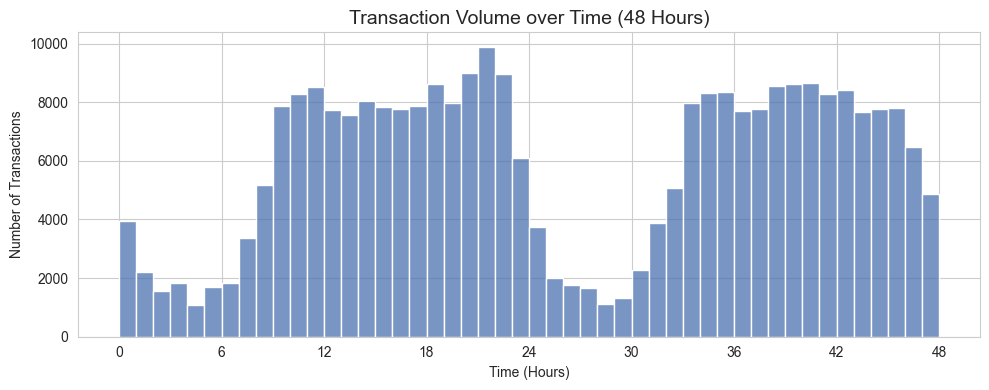

Conclusion:
The Time feature shows a bimodal distribution representing a 48-hour (2-day) cycle, clearly showing daytime peaks and nighttime lulls.
Fraud is an adversarial, time-series problem. Adversaries change tactics over time. If we randomly shuffle this data, we will leak future fraud patterns into our training set.
Solution: We must sort the dataset by Time and split chronologically (Train -> Val -> Test) to accurately simulate production.


In [17]:
plt.figure(figsize=(10,4))
sns.set_style("whitegrid")

# Convert seconds to hours for better readability
hours = df['Time'] / 3600

ax = sns.histplot(
    hours,
    bins=48, 
    color='#4C72B0',
    kde=False
)

plt.title('Transaction Volume over Time (48 Hours)', fontsize=14)
plt.xlabel('Time (Hours)')
plt.ylabel('Number of Transactions')
plt.xticks(np.arange(0, 54, 6))

plt.tight_layout()
plt.show()

# Engineering interpretation
print("Conclusion:")
print("The Time feature shows a bimodal distribution representing a 48-hour (2-day) cycle, clearly showing daytime peaks and nighttime lulls.")
print("Fraud is an adversarial, time-series problem. Adversaries change tactics over time. If we randomly shuffle this data, we will leak future fraud patterns into our training set.")
print("Solution: We must sort the dataset by Time and split chronologically (Train -> Val -> Test) to accurately simulate production.")